<a href="https://colab.research.google.com/github/kamryonjohnson/cloud-computers-models/blob/main/senior_design.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

price_df = pd.read_parquet('/content/price_table.parquet')
price_df.head()

,id,commodity,timestamp,close
0,6603,WTI,2026-01-11 23:00:00,59.599998
1,6604,WTI,2026-01-12 00:00:00,59.450001
2,6605,WTI,2026-01-12 01:00:00,58.790001
3,6606,WTI,2026-01-12 02:00:00,59.160000
4,6607,WTI,2026-01-12 03:00:00,59.180000


In [2]:
news_df = pd.read_parquet('/content/news_table.parquet')
news_df.head()

,date,published_at,source,author,title,description,content,url
0,2026-03-22,2026-03-22 18:37:41+00:00,ABC News (AU),Alan Kohler,Iran war's damage to economy could worsen yet ...,The markets' benign assessment of the Iran war...,Markets are more worried about the war in Iran...,https://www.abc.net.au/news/2026-03-23/energy-...
1,2026-03-22,2026-03-22 18:37:59+00:00,Freerepublic.com,youtube.com/,"The ""Righteous"" Village: How a Protestant Town...","3,000 Jewish children vanished from the face o...","3,000 Jewish children vanished from the face o...",https://freerepublic.com/focus/f-chat/4371756/...
2,2026-03-22,2026-03-22 18:38:46+00:00,New York Post,Jeremy Louwerse,Insane way thief is busted stealing 500 gallon...,The suspect is accused of pumping the liquid g...,A man alleged to have stolen 500 gallons of di...,https://nypost.com/2026/03/22/us-news/las-vega...
3,2026-03-22,2026-03-22 18:40:17+00:00,Bringatrailer.com,bringatrailer,1982 Chevrolet G20 Day Cruiser Conversion Van ...,This 1982 Chevrolet G20 van was upfitted by Da...,This 1982 Chevrolet G20 van was upfitted by Da...,https://bringatrailer.com/listing/1982-chevrol...
4,2026-03-22,2026-03-22 18:41:18+00:00,USA Today,"Dylan McNeill, UCLA Wire",UCLA's freshman Sienna Betts has a strong NCAA...,Lauren and Sienna Betts both notched double-do...,"Going into the NCAA tournament, UCLA Bruins fr...",https://uclawire.usatoday.com/story/sports/col...


In [3]:
price_df['timestamp'] = pd.to_datetime(price_df['timestamp'])

missing_values_price = price_df.isnull().sum()
print("Missing Values in Price Table:")
print(missing_values_price)

Missing Values in Price Table:
id           0
commodity    0
timestamp    0
close        0
dtype: int64


In [6]:
news_df['published_at'] = pd.to_datetime(news_df['published_at'])
news_df['date'] = pd.to_datetime(news_df['date'])

missing_values_news = news_df.isnull().sum()
print("Missing Values in news Table:")
print(missing_values_news)

Missing Values in news Table:
date             0
published_at     0
source           0
author          11
title            0
description      2
content          0
url              0
\date            0
dtype: int64


In [7]:
news_df['author'] = news_df['author'].fillna('unknown')
news_df['description'] = news_df['description'].fillna('no desription available')

missing_values_news_after_filling = news_df.isnull().sum()
print("Missing Values in news Table after filling:")
print(missing_values_news_after_filling)


Missing Values in news Table after filling:
date            0
published_at    0
source          0
author          0
title           0
description     0
content         0
url             0
\date           0
dtype: int64


In [11]:
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

try:
    nltk.data.find('sentiment/vader_lexicon.zip')
except LookupError:
   nltk.download('vader_lexicon')

sia=SentimentIntensityAnalyzer()
news_df['sentiment_score'] = news_df['title'].apply(lambda title: sia.polarity_scores(title)['compound'])
print(news_df[['title', 'sentiment_score']].head())


                                               title  sentiment_score
0  Iran war's damage to economy could worsen yet ...          -0.7783
1  The "Righteous" Village: How a Protestant Town...          -0.1027
2  Insane way thief is busted stealing 500 gallon...          -0.9545
3  1982 Chevrolet G20 Day Cruiser Conversion Van ...          -0.2960
4  UCLA's freshman Sienna Betts has a strong NCAA...           0.5106


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


In [15]:
news_df['hourly_timestamp'] = news_df['published_at'].dt.floor('h')
hourly_sentiment = news_df.groupby('hourly_timestamp')['sentiment_score'].mean().reset_index()
hourly_sentiment = hourly_sentiment.rename(columns={'hourly_timestamp': 'timestamp', 'sentiment_score': 'avg_sentiment_score'})

# Ensure both timestamp columns are timezone-aware UTC before merging
price_df['timestamp'] = price_df['timestamp'].dt.tz_localize(None).dt.floor('h').dt.tz_localize('UTC')
hourly_sentiment['timestamp'] = hourly_sentiment['timestamp'].dt.tz_localize(None).dt.floor('h').dt.tz_localize('UTC')

merged_df = pd.merge(price_df, hourly_sentiment, on='timestamp', how='left')

# Fill any missing sentiment scores (e.g., hours with no news) with 0 or the mean
merged_df['avg_sentiment_score'] = merged_df['avg_sentiment_score'].fillna(0)

print("Merged DataFrame with hourly sentiment:")
display(merged_df.head())

Merged DataFrame with hourly sentiment:


,id,commodity,timestamp,close,avg_sentiment_score
0,6603,WTI,2026-01-11 23:00:00+00:00,59.599998,0.0
1,6604,WTI,2026-01-12 00:00:00+00:00,59.450001,0.0
2,6605,WTI,2026-01-12 01:00:00+00:00,58.790001,0.0
3,6606,WTI,2026-01-12 02:00:00+00:00,59.160000,0.0
4,6607,WTI,2026-01-12 03:00:00+00:00,59.180000,0.0


In [16]:
# Create lag features for 'close' price
for i in range(1, 4): # Lag up to 3 hours
    merged_df[f'close_lag_{i}'] = merged_df['close'].shift(i)

# Create lag features for 'avg_sentiment_score'
for i in range(1, 4): # Lag up to 3 hours
    merged_df[f'sentiment_lag_{i}'] = merged_df['avg_sentiment_score'].shift(i)

# Define the target variable: price change in the next hour
merged_df['price_change_next_hour'] = merged_df['close'].shift(-1) - merged_df['close']

# Drop rows with NaN values resulting from lags and the target variable calculation
merged_df = merged_df.dropna()

print("DataFrame with lag features and target variable:")
display(merged_df.head())

DataFrame with lag features and target variable:


,id,commodity,timestamp,close,avg_sentiment_score,close_lag_1,close_lag_2,close_lag_3,sentiment_lag_1,sentiment_lag_2,sentiment_lag_3,price_change_next_hour
3,6606,WTI,2026-01-12 02:00:00+00:00,59.160000,0.0,58.790001,59.450001,59.599998,0.0,0.0,0.0,0.020000
4,6607,WTI,2026-01-12 03:00:00+00:00,59.180000,0.0,59.160000,58.790001,59.450001,0.0,0.0,0.0,0.020000
5,6608,WTI,2026-01-12 04:00:00+00:00,59.200001,0.0,59.180000,59.160000,58.790001,0.0,0.0,0.0,0.090000
6,6609,WTI,2026-01-12 05:00:00+00:00,59.290001,0.0,59.200001,59.180000,59.160000,0.0,0.0,0.0,-0.060001
7,6610,WTI,2026-01-12 06:00:00+00:00,59.230000,0.0,59.290001,59.200001,59.180000,0.0,0.0,0.0,-0.279999


Model Performance:
Mean Absolute Error (MAE): 0.4094
Mean Squared Error (MSE): 2.5740
Root Mean Squared Error (RMSE): 1.6044


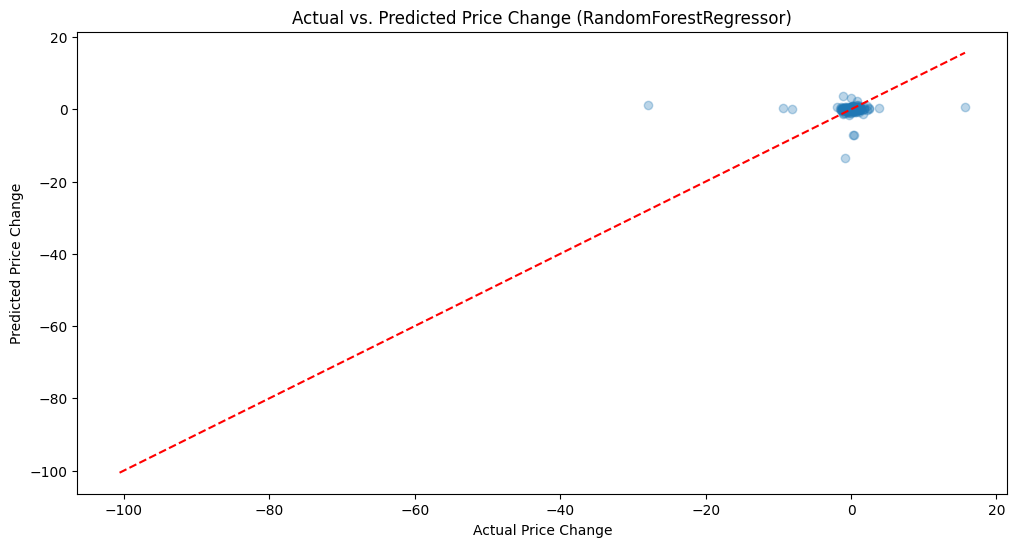

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import pandas as pd

# Define features (X) and target (y)
features = [col for col in merged_df.columns if 'lag' in col or col == 'avg_sentiment_score']
X = merged_df[features]
y = merged_df['price_change_next_hour']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the RandomForestRegressor model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse**0.5

print(f"Model Performance:")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

# Visualize predictions vs actual values
plt.figure(figsize=(12, 6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.xlabel("Actual Price Change")
plt.ylabel("Predicted Price Change")
plt.title("Actual vs. Predicted Price Change (RandomForestRegressor)")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--') # Diagonal line
plt.show()

In [23]:
# Get the last row of the merged_df to extract the most recent lag features and sentiment
last_data_point = merged_df.tail(1)

# Extract the latest close price and sentiment lags
latest_close = last_data_point['close'].values[0]
latest_sentiment_lag_1 = last_data_point['avg_sentiment_score'].values[0]
latest_sentiment_lag_2 = last_data_point['sentiment_lag_1'].values[0]
latest_sentiment_lag_3 = last_data_point['sentiment_lag_2'].values[0]

print(f"Latest Close Price: {latest_close:.2f}")
print(f"Latest Average Sentiment Score: {latest_sentiment_lag_1:.4f}")

Latest Close Price: 2.92
Latest Average Sentiment Score: 0.0000


In [24]:
new_headline = "USA going to war, global markets plunge and oil prices soar due to conflict escalation."
new_sentiment_score = sia.polarity_scores(new_headline)['compound']

print(f"New Headline: {new_headline}")
print(f"Sentiment Score for new headline: {new_sentiment_score:.4f}")

New Headline: USA going to war, global markets plunge and oil prices soar due to conflict escalation.
Sentiment Score for new headline: -0.7351


In [25]:
import pandas as pd

# Create a DataFrame for the new input, mirroring the feature structure
X_new = pd.DataFrame({
    'avg_sentiment_score': [new_sentiment_score], # The sentiment of the new headline
    'close_lag_1': [latest_close], # The previous hour's close price becomes lag_1
    'close_lag_2': [last_data_point['close_lag_1'].values[0]], # Shift existing lags
    'close_lag_3': [last_data_point['close_lag_2'].values[0]], # Shift existing lags
    'sentiment_lag_1': [latest_sentiment_lag_1], # The previous hour's sentiment becomes lag_1
    'sentiment_lag_2': [latest_sentiment_lag_2], # Shift existing sentiment lags
    'sentiment_lag_3': [latest_sentiment_lag_3]  # Shift existing sentiment lags
}, index=[0])

display(X_new)


,avg_sentiment_score,close_lag_1,close_lag_2,close_lag_3,sentiment_lag_1,sentiment_lag_2,sentiment_lag_3
0,-0.7351,2.919,2.935,2.915,0.0,0.0,0.0


In [26]:
predicted_price_change = model.predict(X_new)

print(f"Predicted price change for the next hour: {predicted_price_change[0]:.4f}")
print(f"This means the model predicts the price will {'increase' if predicted_price_change[0] > 0 else 'decrease'} by {abs(predicted_price_change[0]):.4f} in the next hour.")

Predicted price change for the next hour: -0.0040
This means the model predicts the price will decrease by 0.0040 in the next hour.
